# Individual Analysis

## Research Question 2: Individual Networks vs Merged Network


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


In [8]:
# Load raw data
df = pd.read_csv('data/df_alter.csv')

# Find which participants mentioned AI
ai_participants = df[df['name'] == 'AI']['participant_id'].unique()
print(f"Total participants: {df['participant_id'].nunique()}")
print(f"Participants who mentioned AI: {len(ai_participants)} ({len(ai_participants)/df['participant_id'].nunique()*100:.0f}%)")

# For each concept, check if it co-occurred with AI in any individual network
concept_stats = []
for concept in df['name'].unique():
    if concept == 'AI':
        continue
    concept_participants = df[df['name'] == concept]['participant_id'].unique()
    cooccurs_with_ai = len(set(concept_participants) & set(ai_participants)) > 0
    
    concept_stats.append({
        'concept': concept,
        'total_mentions': len(concept_participants),
        'cooccurs_with_ai': cooccurs_with_ai
    })

stats_df = pd.DataFrame(concept_stats)

# Compare groups
with_ai = stats_df[stats_df['cooccurs_with_ai'] == True]
without_ai = stats_df[stats_df['cooccurs_with_ai'] == False]

print(f"\nConcepts WITH AI: n={len(with_ai)}, avg mentions={with_ai['total_mentions'].mean():.1f}")
print(f"Concepts WITHOUT AI: n={len(without_ai)}, avg mentions={without_ai['total_mentions'].mean():.1f}")
print(f"Ratio: {with_ai['total_mentions'].mean() / without_ai['total_mentions'].mean():.2f}x")

# Statistical test
t_stat, p_value = stats.ttest_ind(with_ai['total_mentions'], without_ai['total_mentions'])
print(f"T-test: t={t_stat:.2f}, p={p_value:.4f}")


Total participants: 17
Participants who mentioned AI: 15 (88%)

Concepts WITH AI: n=36, avg mentions=4.7
Concepts WITHOUT AI: n=1, avg mentions=2.0
Ratio: 2.35x
T-test: t=0.86, p=0.3966


## Visualization


/var/folders/6x/0dzzyfsd4078wfgbndq284380000gn/T/ipykernel_21278/967981821.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([with_ai['total_mentions'], without_ai['total_mentions']],


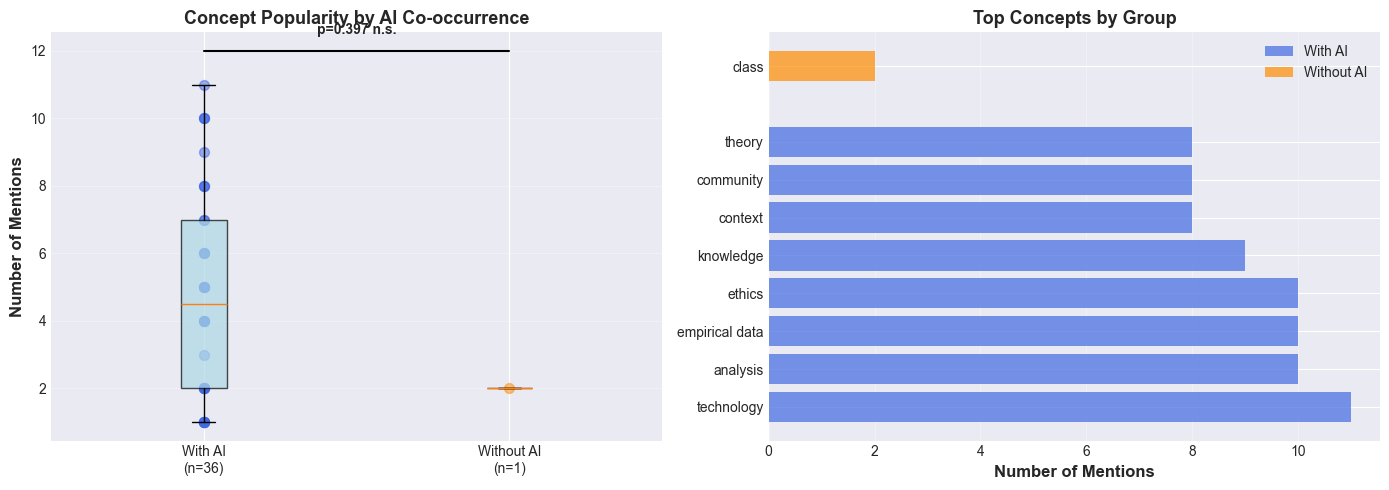

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Box plot
plot_data = pd.concat([
    pd.DataFrame({'group': 'With AI', 'mentions': with_ai['total_mentions']}),
    pd.DataFrame({'group': 'Without AI', 'mentions': without_ai['total_mentions']})
])

axes[0].boxplot([with_ai['total_mentions'], without_ai['total_mentions']], 
                labels=['With AI\n(n={})'.format(len(with_ai)), 
                       'Without AI\n(n={})'.format(len(without_ai))],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[0].scatter([1]*len(with_ai), with_ai['total_mentions'], alpha=0.5, s=50, color='royalblue')
axes[0].scatter([2]*len(without_ai), without_ai['total_mentions'], alpha=0.5, s=50, color='darkorange')
axes[0].set_ylabel('Number of Mentions', fontsize=12, fontweight='bold')
axes[0].set_title('Concept Popularity by AI Co-occurrence', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Add significance line
y_max = max(with_ai['total_mentions'].max(), without_ai['total_mentions'].max())
axes[0].plot([1, 2], [y_max + 1, y_max + 1], 'k-', linewidth=1.5)
sig = '***' if p_value < 0.001 else ('**' if p_value < 0.01 else ('*' if p_value < 0.05 else 'n.s.'))
axes[0].text(1.5, y_max + 1.5, f'p={p_value:.3f} {sig}', ha='center', fontweight='bold')

# Right plot: Bar chart of top concepts
top_with = with_ai.nlargest(8, 'total_mentions')
top_without = without_ai.nlargest(5, 'total_mentions')

y_pos_with = np.arange(len(top_with))
y_pos_without = np.arange(len(top_without)) + len(top_with) + 1

axes[1].barh(y_pos_with, top_with['total_mentions'], color='royalblue', alpha=0.7, label='With AI')
axes[1].barh(y_pos_without, top_without['total_mentions'], color='darkorange', alpha=0.7, label='Without AI')

axes[1].set_yticks(list(y_pos_with) + list(y_pos_without))
axes[1].set_yticklabels(list(top_with['concept']) + list(top_without['concept']))
axes[1].set_xlabel('Number of Mentions', fontsize=12, fontweight='bold')
axes[1].set_title('Top Concepts by Group', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('individual_analysis_jiaqi.png', dpi=300, bbox_inches='tight')
plt.show()



## Claim :

The merged network treats all concepts as equal, but individual networks show that some concepts never appear with AI. By merging data, we lose the ability to see which concepts people don't mentally connect with AI.